<a href="https://colab.research.google.com/github/mafgit/developershub-internship-tasks/blob/master/Task_2_Predict_Future_Stock_Prices_(Short_Term).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 2: Predict Future Stock Prices (Short-Term)

In [67]:
import yfinance as yf

df = yf.download('TSLA', period='2y')

df.head()

/tmp/ipykernel_18402/46362875.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('TSLA', period='2y')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2024-04-29,194.050003,198.869995,184.539993,188.419998,243869700
2024-04-30,183.279999,190.949997,182.839996,186.979996,127031800
2024-05-01,179.990005,185.860001,179.009995,182.000000,92829700
2024-05-02,180.009995,184.600006,176.020004,182.860001,89148000
2024-05-03,181.190002,184.779999,178.419998,182.100006,75491500


In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 500 entries, 2024-04-29 to 2026-04-27
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, TSLA)   500 non-null    float64
 1   (High, TSLA)    500 non-null    float64
 2   (Low, TSLA)     500 non-null    float64
 3   (Open, TSLA)    500 non-null    float64
 4   (Volume, TSLA)  500 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 23.4 KB


In [69]:
data = df.copy()

data["Close Tomorrow"] = data["Close"].shift(-1)
data.dropna(inplace=True)

### Splitting & training

In [70]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor


from sklearn.model_selection import train_test_split
train_data, test_data = train_test_split(data, test_size=0.1, random_state=42)
X_cols = ["High", "Low", "Open", "Volume", "Close"]
y_col = "Close Tomorrow"

X = train_data[X_cols]
y = train_data[y_col]

lr_model = LinearRegression()
rf_model = RandomForestRegressor()

lr_model.fit(X, y)
rf_model.fit(X, y)


RandomForestRegressor()

### Prediction & plotting comparison

In [72]:
X_test = test_data[X_cols]
y_test = test_data[y_col]

y_pred_lr = lr_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

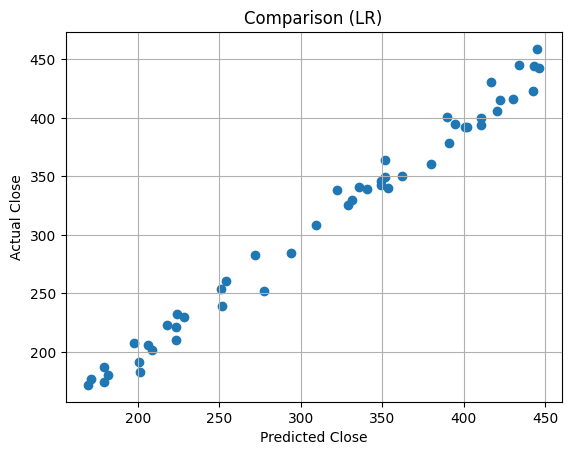

In [85]:
import matplotlib.pyplot as plt
plt.title("Comparison (LR)")
plt.ylabel("Actual Close")
plt.xlabel("Predicted Close")
plt.grid()
plt.scatter(y_pred_lr, y_test)
plt.show()

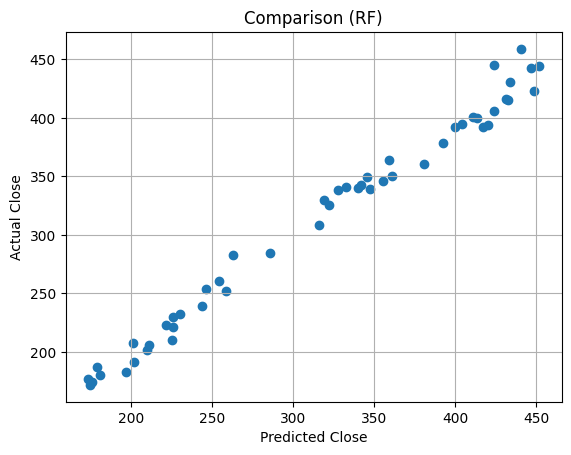

In [84]:
plt.title("Comparison (RF)")
plt.ylabel("Actual Close")
plt.xlabel("Predicted Close")
plt.grid()
plt.scatter(y_pred_rf, y_test)
plt.show()